Dispositivo: cuda


Fetching ... files: 0it [00:00, ?it/s]

Dataset downloaded in:
/root/.cache/huggingface/hub/datasets--InesBerdinas--calligraphy-classification-dataset/snapshots/661627fc1cd3ff3558e1da6fda3a555d1304f59d

Founded classes:
['Persona_01', 'Persona_02', 'Persona_03', 'Persona_04', 'Persona_05']

Wheights downloaded correctly
Model loaded correctly

Total images selected: 10


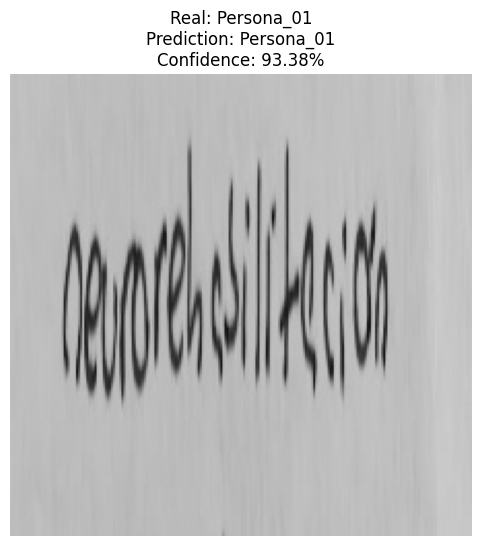

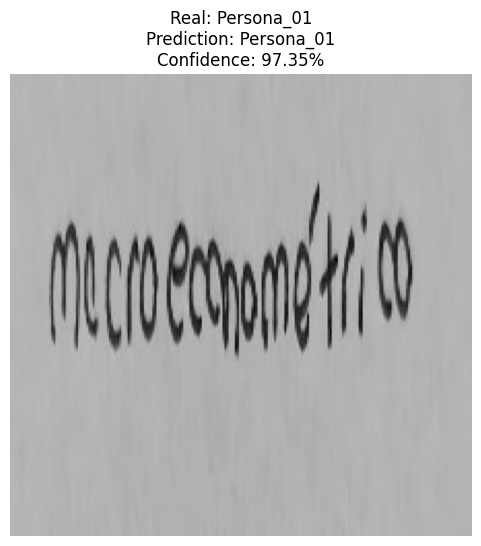

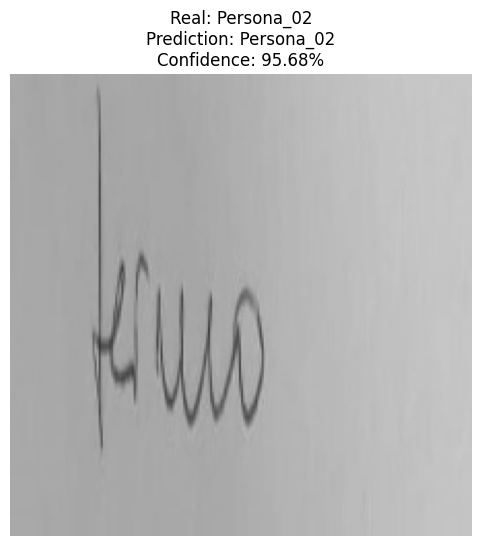

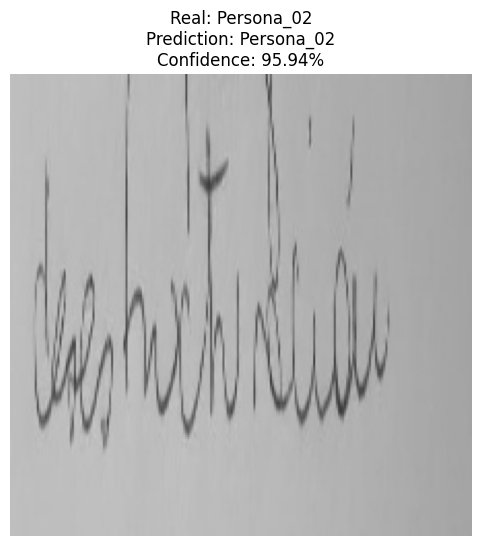

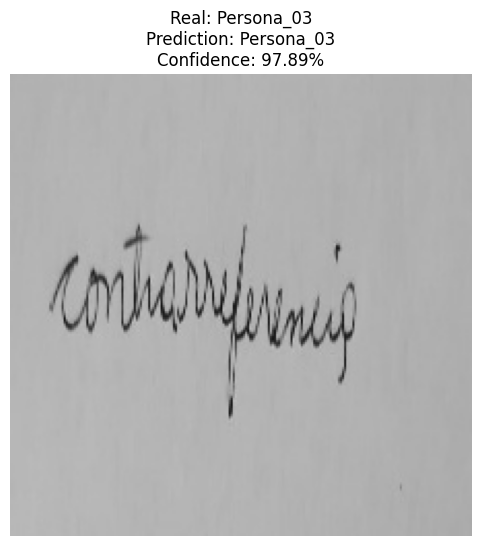

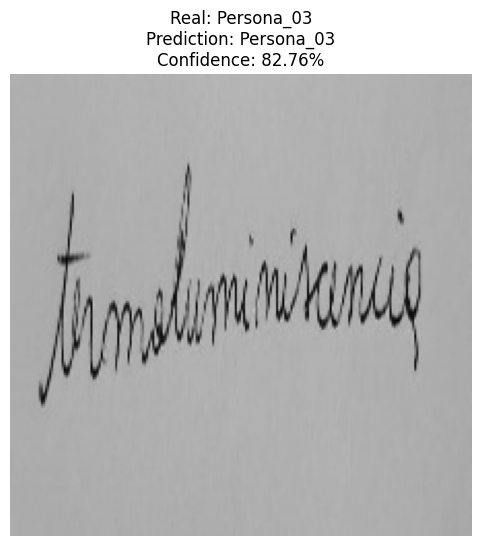

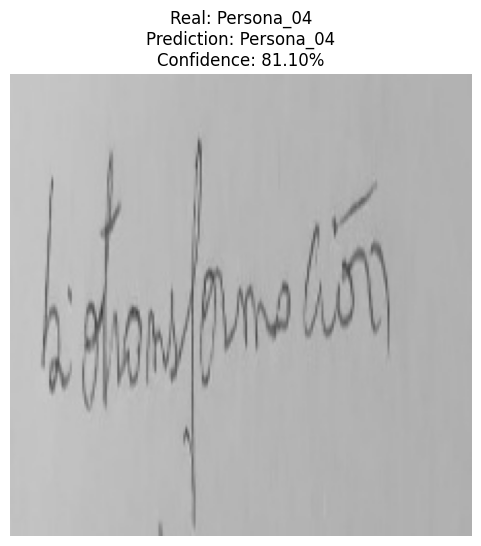

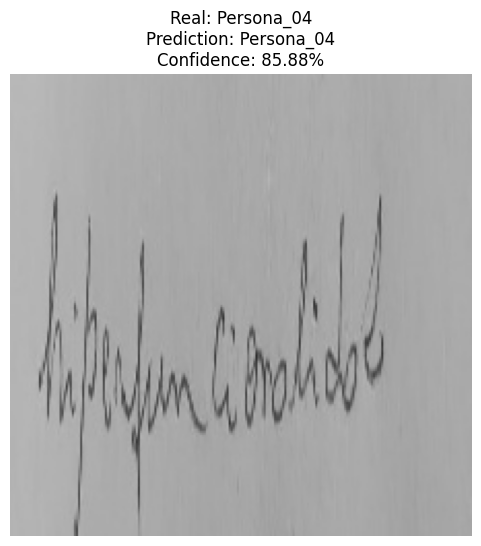

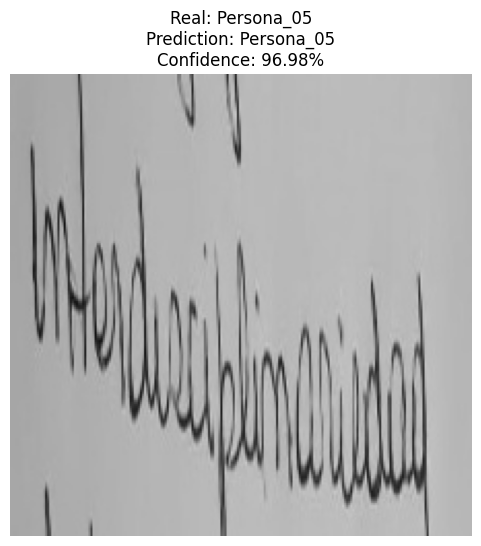

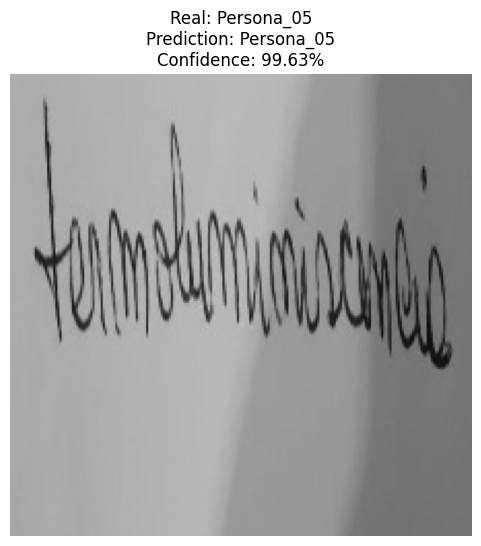


Accuracy: 100.00%
Correct: 10
Total: 10


In [2]:
# ============================================================
# INSTALATION
# ============================================================

!pip install -q huggingface_hub

# ============================================================
# IMPORTS
# ============================================================

import os
import random
import requests
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from huggingface_hub import snapshot_download

from torchvision import datasets, transforms, models

# ============================================================
# CONFIGURATIONS
# ============================================================

HF_DATASET_REPO = "InesBerdinas/calligraphy-classification-dataset"

WEIGHTS_URL = (
    "https://raw.githubusercontent.com/"
    "InesBerdinas/calligraphy-classification/main/"
    "fine_tuning_weights.pth"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", DEVICE)

# ============================================================
# DOWNLOAD DATASET FROM HUGGING FACE
# ============================================================

print("Downloading dataset...")

dataset_path = snapshot_download(
    repo_id=HF_DATASET_REPO,
    repo_type="dataset"
)

print("Dataset downloaded in:")
print(dataset_path)

TRAIN_DIR = os.path.join(dataset_path, "train")
TEST_DIR = os.path.join(dataset_path, "test")

# ============================================================
# OBTAIN CLASSES
# ============================================================

train_dataset = datasets.ImageFolder(TRAIN_DIR)

CLASS_NAMES = train_dataset.classes

print("\nFounded classes:")
print(CLASS_NAMES)

NUM_CLASSES = len(CLASS_NAMES)

# ============================================================
# DOWNLOAD WEIGHTS FROM GITHUB
# ============================================================

print("\nDownloading weights...")

weights_path = "best.pt"

response = requests.get(WEIGHTS_URL)

if response.status_code != 200:
    raise Exception(
        f"Error downloading weights. "
        f"Status code: {response.status_code}"
    )

with open(weights_path, "wb") as f:
    f.write(response.content)

print("Wheights downloaded correctly")

# ============================================================
# CREAR MODELO
# ============================================================

model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=NUM_CLASSES
)

# ============================================================
# CARGAR PESOS
# ============================================================

state_dict = torch.load(
    weights_path,
    map_location=DEVICE
)

model.load_state_dict(state_dict)

model.to(DEVICE)

model.eval()

print("Model loaded correctly")

# ============================================================
# TRANSFORMATIONS
# ============================================================

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# SELECT 2 IMAGES RANDOMLY PER CLASS
# ============================================================

selected_images = []

for class_name in CLASS_NAMES:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    images = [
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if len(images) == 0:
        continue

    chosen = random.sample(
        images,
        min(2, len(images))
    )

    for img_path in chosen:
        selected_images.append(
            (img_path, class_name)
        )

print(
    f"\nTotal images selected: "
    f"{len(selected_images)}"
)

# ============================================================
# INFERENCE
# ============================================================

correct = 0
total = 0

for image_path, true_label in selected_images:

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = inference_transform(
        image
    ).unsqueeze(0)

    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = CLASS_NAMES[
        prediction.item()
    ]

    confidence = confidence.item() * 100

    if predicted_label == true_label:
        correct += 1

    total += 1

    plt.figure(figsize=(6, 6))

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Real: {true_label}\n"
        f"Prediction: {predicted_label}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()

# ============================================================
# FINAL RESULT
# ============================================================

accuracy = 100 * correct / total

print("\n" + "=" * 50)
print(f"Accuracy: {accuracy:.2f}%")
print(f"Correct: {correct}")
print(f"Total: {total}")
print("=" * 50)